## VAE Encoder + XGBoost
Pipeline baseado em Variational Autoencoders especializados, um por classe clínica. Os vetores latentes extraídos de cada VAE são concatenados e utilizados como entrada para um classificador XGBoost.

## Imports necessários

In [1]:
!pip install -q xgboost scikit-learn



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\beatr\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
import seaborn as sns

from xgboost import XGBClassifier

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE   = 128 # tamanho da imagem
BATCH_SIZE = 8

print(f'Device: {DEVICE}')

Device: cuda


## Caminhos e VAEs

In [3]:
base_dir = './dataset_monica'
# Caminhos para os modelos VAE especializados por classe
VAE_PATHS = {
    'Biliary_Leaks' : './vae_perceptual_biliary.pth',
    'Normal'        : './vae_perceptual_normal.pth',
    'Stricture'     : './vae_perceptual_Stricture.pth',
    }

print('base_dir existe:', os.path.isdir(base_dir))

for phase in ['train', 'val', 'test']:
    p = os.path.join(base_dir, phase)
    print(f'  {phase}/  existe: {os.path.isdir(p)}')

base_dir existe: True
  train/  existe: True
  val/  existe: True
  test/  existe: True


## Carregar Dataset

In [4]:
valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
phases     = ['train', 'val', 'test']

# Descobrir classes a partir da pasta train
class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names) # Número total de classes
print('Classes:', class_names)
print('Num classes:', num_class)

valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def load_split(phase):
    images, labels = [], []
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        if not os.path.isdir(class_dir):
            continue
        files = [os.path.join(class_dir, f) for f in os.listdir(class_dir)
                 if f.lower().endswith(valid_exts)]
        images.extend(files)
        labels.extend([i] * len(files))
    print(f'{phase.capitalize():6s}: {len(images)} imagens')
    return images, labels

# Carregamento dos conjuntos de treino, validação e teste
train_images, train_labels = load_split('train')
val_images,   val_labels   = load_split('val')
test_images,  test_labels  = load_split('test')


Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Num classes: 4
Train : 1067 imagens
Val   : 234 imagens
Test  : 267 imagens


## Transforms e DataLoaders
Criação da classe Dataset e dos DataLoaders utilizados para percorrer eficientemente os conjuntos de treino, validação e teste durante a extração de features.

In [5]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # VAE treinado com 3 canais
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # redimensiona para 128×128
    transforms.ToTensor(), # converte para tensor
])

# classe dataset
class MedDataset(Dataset):
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]

train_ds = MedDataset(train_images, train_labels, transform)
val_ds   = MedDataset(val_images,   val_labels,   transform)
test_ds  = MedDataset(test_images,  test_labels,  transform)
# criação dos datasets e dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 1067 | Val: 234 | Test: 267


## Definição da arquitectura do VAE

In [6]:
import torch.nn as nn
# Definição da Arquitetura ConvVAE
class ConvVAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=256, img_size=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.img_size   = img_size

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )
        self.feat_size = img_size // 16
        self.flat_dim  = 256 * self.feat_size * self.feat_size

        self.fc_mu      = nn.Linear(self.flat_dim, latent_dim)
        self.fc_log_var = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode  = nn.Linear(latent_dim, self.flat_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, in_channels, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        if self.training:
            return mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)
        return mu

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 256, self.feat_size, self.feat_size)
        return self.decoder(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var, z

print('ConvVAE definido')

ConvVAE definido


## Carregamento dos VAEs Especializados

In [7]:
# Carrega os modelos VAE treinados individualmente para cada classe
vaes = {}
for class_name, path in VAE_PATHS.items():
    if class_name not in class_names:
        print(f'  {class_name}: não está nas classes - a saltar')
        continue
    if not os.path.isfile(path):
        print(f'  {class_name}: ficheiro não encontrado - {path}')
        continue
    vae = torch.load(path, map_location=DEVICE, weights_only=False)
    vae.eval()
    vaes[class_name] = vae
    print(f'VAE {class_name} carregado')

print(f'\nVAEs carregados: {list(vaes.keys())}')

VAE Biliary_Leaks carregado
VAE Normal carregado
VAE Stricture carregado

VAEs carregados: ['Biliary_Leaks', 'Normal', 'Stricture']


## Extração de features

In [8]:
def extract_features_vae(dataloader, vaes, class_names, device):
    all_features, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            mus  = []

            for class_name in class_names:
                if class_name in vaes:
                    mu, _ = vaes[class_name].encode(imgs)
                    mus.append(mu.cpu().numpy())

            # Concatena mu de todos os VAEs para formar o vetor de features 
            features = np.concatenate(mus, axis=1)
            all_features.append(features)
            all_labels.append(lbls.numpy())

    return np.concatenate(all_features), np.concatenate(all_labels)


# Geração das Features para Treino, Validação e Teste
print('A extrair features...')
X_train, y_train = extract_features_vae(train_loader, vaes, class_names, DEVICE)
X_val,   y_val   = extract_features_vae(val_loader,   vaes, class_names, DEVICE)
X_test,  y_test  = extract_features_vae(test_loader,  vaes, class_names, DEVICE)

print(f'X_train: {X_train.shape}')
print(f'X_val  : {X_val.shape}')
print(f'X_test : {X_test.shape}')

A extrair features...
X_train: (1067, 768)
X_val  : (234, 768)
X_test : (267, 768)


## XGBoost com Class Weights

In [9]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train) # calcula pesos automaticamente
sample_weights = np.array([weights[l] for l in y_train])

print('Class weights:')
for name, w in zip(class_names, weights):
    print(f'  {name}: {w:.4f}')

# configuração xgboost
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=num_class,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42
)

print('\nA treinar XGBoost...')
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=50
)

Class weights:
  Biliary_Leaks: 2.4250
  Lithiasis: 0.5282
  Normal: 1.3541
  Stricture: 1.0461

A treinar XGBoost...
[0]	validation_0-mlogloss:1.38086
[36]	validation_0-mlogloss:1.35884


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'mlogloss'


## Avaliação Final no teste

=========== TEST SET ===========
Accuracy : 0.3408
F1 Macro : 0.2782

               precision    recall  f1-score   support

Biliary_Leaks     0.3750    0.1765    0.2400        17
    Lithiasis     0.4091    0.5122    0.4549       123
       Normal     0.1778    0.1860    0.1818        43
    Stricture     0.2833    0.2024    0.2361        84

     accuracy                         0.3408       267
    macro avg     0.3113    0.2693    0.2782       267
 weighted avg     0.3301    0.3408    0.3284       267



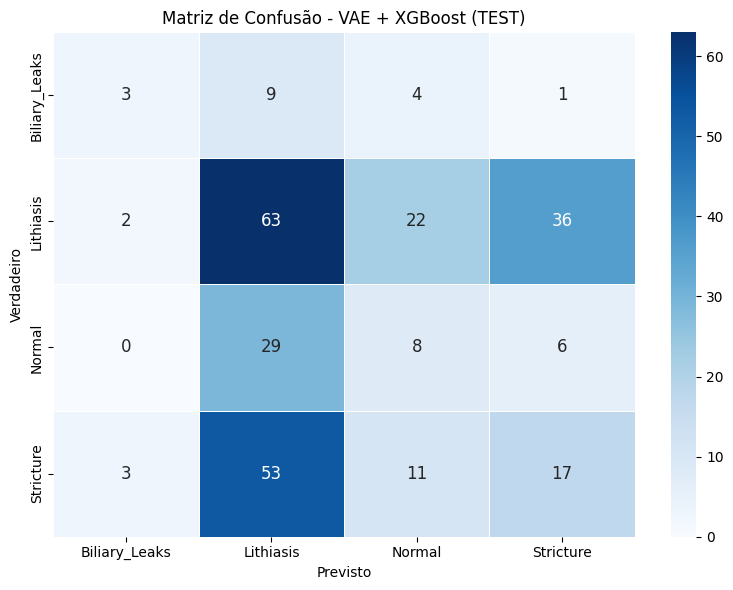

In [10]:
preds = xgb_model.predict(X_test)

acc = accuracy_score(y_test, preds)
f1  = f1_score(y_test, preds, average='macro')

print('=========== TEST SET ===========')
print(f'Accuracy : {acc:.4f}')
print(f'F1 Macro : {f1:.4f}\n')

print(classification_report(y_test, preds,
                             target_names=class_names,
                             digits=4, zero_division=0))

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', linewidths=0.5,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 12}, cmap='Blues')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.title('Matriz de Confusão - VAE + XGBoost (TEST)')
plt.tight_layout()
plt.savefig('confusion_matrix_vae_xgb.png', dpi=300)
plt.show()